# Libraries

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
from sklearn.datasets import load_diabetes

# Dataset

In [43]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [44]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [45]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [46]:
feature = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

# Formatting Data

In [47]:
# Missing data 
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq  = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


In [48]:
# Label Encoding 
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [49]:
# Splitting dataset
X = titanic[feature]
y = titanic[target]

In [61]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.3,
random_state=42,
shuffle=True
)

In [62]:
X_test.head(5)

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


# Model 

In [63]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [64]:
y_pred = model.predict(X_test)
print(f"accuracy score: {accuracy_score(y_pred, y_test):.4f}")

accuracy score: 0.7537


Enter Max Depth:  2


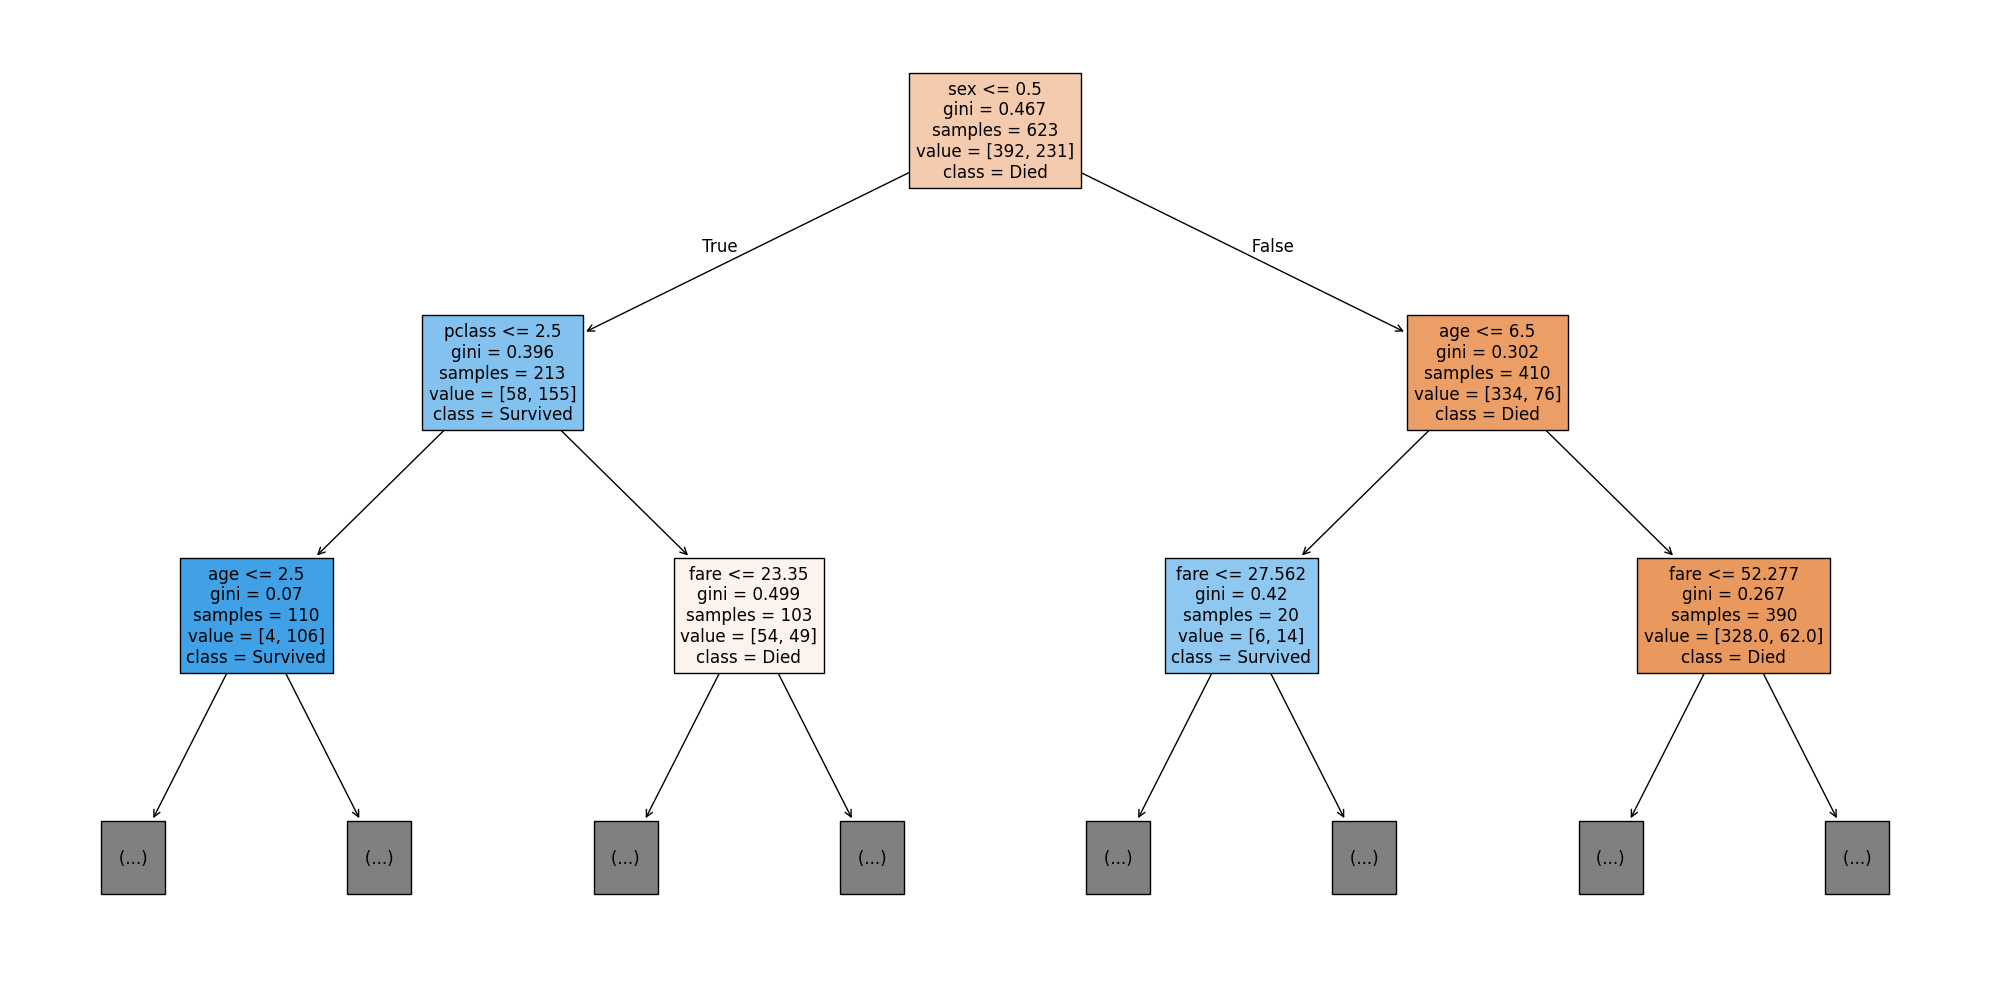

In [75]:
depth = int(input("Enter Max Depth: "))
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled = True,
    max_depth=depth
    
)
plt.tight_layout()
plt.show()

# Decision Tree Classifiers

Decision Tree with Pre-Pruning !!

In [ ]:
# MAX DEPTH
max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths: 
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    score= model.score(X_test,y_test)
    print(f"For depth- {depth} accuracy score is: {(score):.4f}")

In [88]:
# MIN SAMPLE SPLIT
min_samples_split = [10,15,20,25,30,40,50]

for split in min_samples_split: 
    model = DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(X_train, y_train)

    score= model.score(X_test,y_test)
    print(f"For depth- {split} accuracy score is: {(score):.4f}")

For depth- 10 accuracy score is: 0.8246
For depth- 15 accuracy score is: 0.8172
For depth- 20 accuracy score is: 0.8172
For depth- 25 accuracy score is: 0.8209
For depth- 30 accuracy score is: 0.8209
For depth- 40 accuracy score is: 0.8209
For depth- 50 accuracy score is: 0.8134


Decision Tree with Post-Purning

In [92]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [100]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f"CCP Alphas: {ccp_alphas}")
# train our model for all alphas
tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    acc = model.fit(X_train, y_train)

    tree.append((model,alpha))

CCP Alphas: [0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [108]:
best_acc = 0
best_alpha = 0

for model, alpha in tree:
    curr_acc = model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

print(f"Best Alpha: {best_alpha:.4f}")
print(f"best Accuracy score: {best_acc:.4f}")

Best Alpha: 0.0017
best Accuracy score: 0.8209


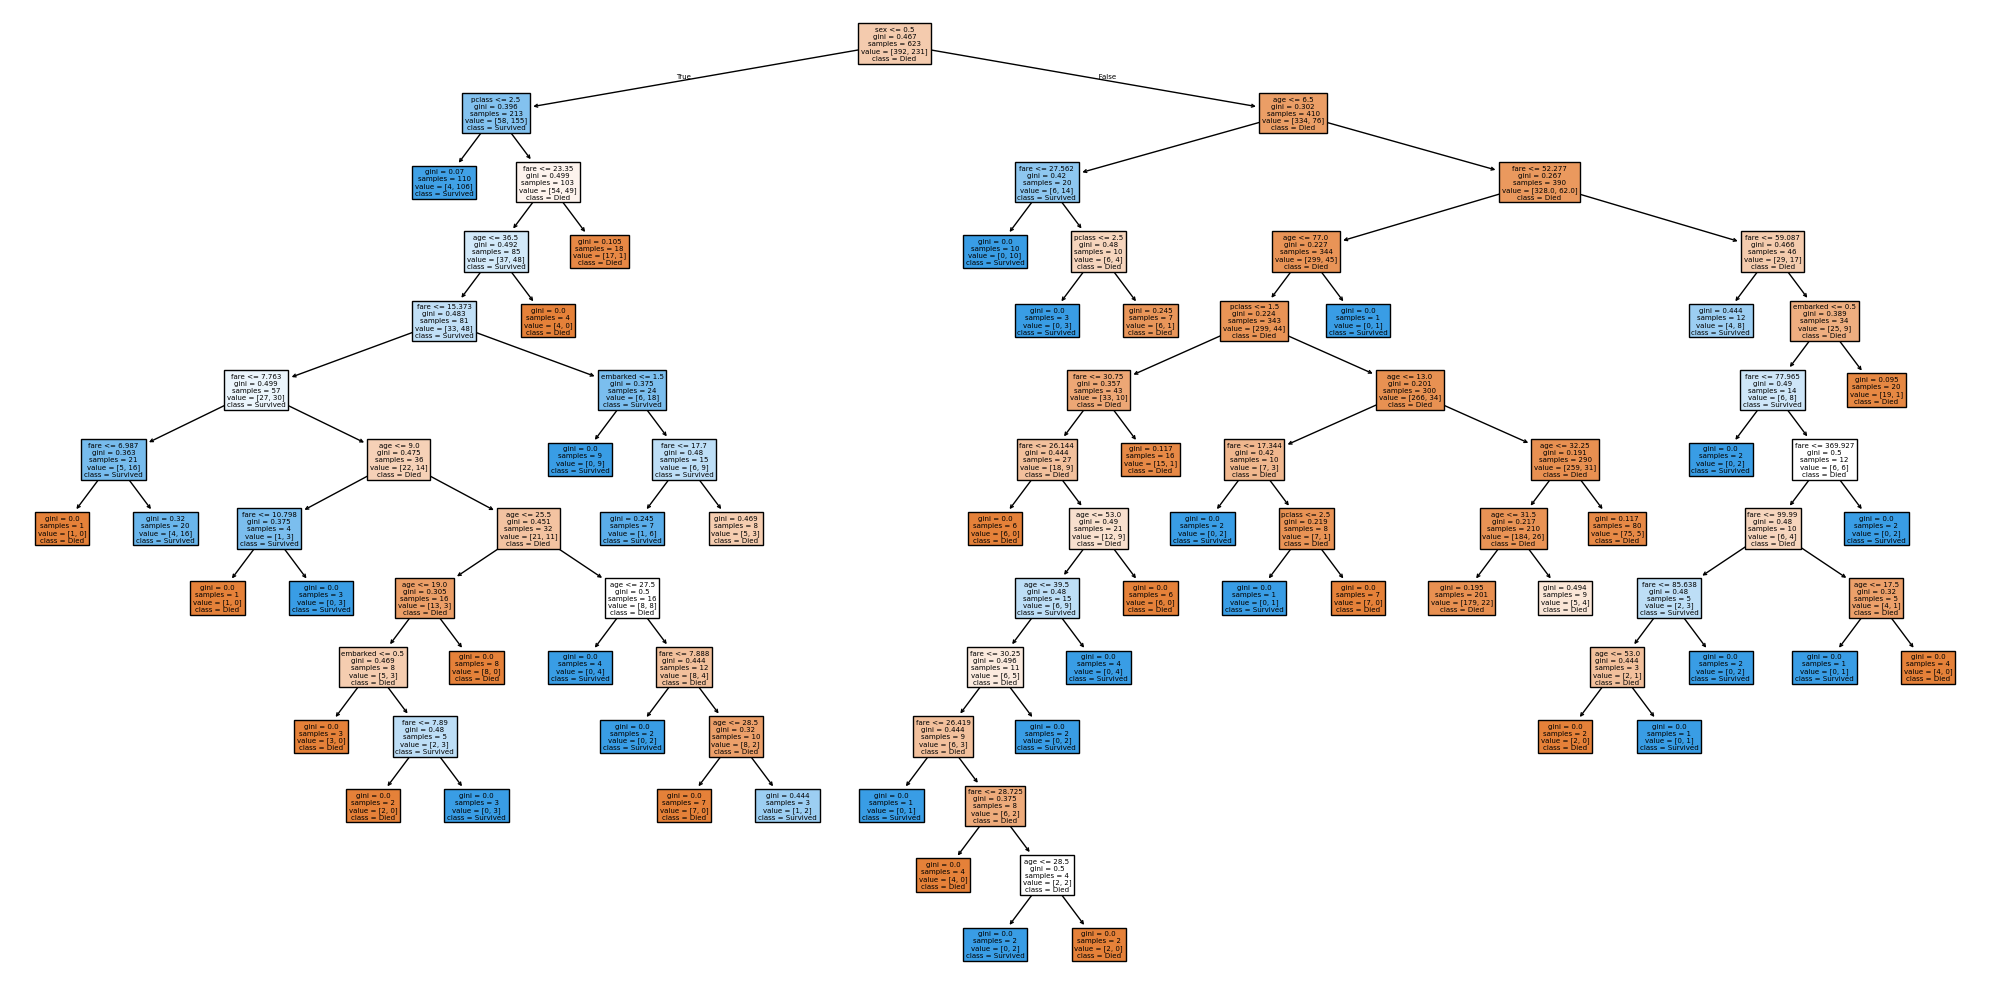

Model Performance: 0.81716


In [114]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled = True,
)
plt.tight_layout()
plt.show()
print(f"Model Performance: {best_model.score(X_test,y_test):.5f}")

# Decision Tree Regressor

In [12]:
data = load_diabetes(as_frame=True).frame
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [16]:
X = data.drop("target",axis=1)
y = data["target"]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

In [33]:
model = DecisionTreeRegressor(max_depth=7, min_samples_split=20, min_samples_leaf=20)
model.fit(X_train,y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Mean Squared Error train: {mean_squared_error(y_train, y_pred_train)}")
print(f"Mean Squared Error test: {mean_squared_error(y_test, y_pred_test)}")

print(f"R2 score train: {r2_score(y_train, y_pred_train)}")
print(f"R2 score test: {r2_score(y_test, y_pred_test)}")

Mean Squared Error train: 2795.7093704335157
Mean Squared Error test: 3177.664925233041
R2 score train: 0.5452860742356658
R2 score test: 0.41135906558189406


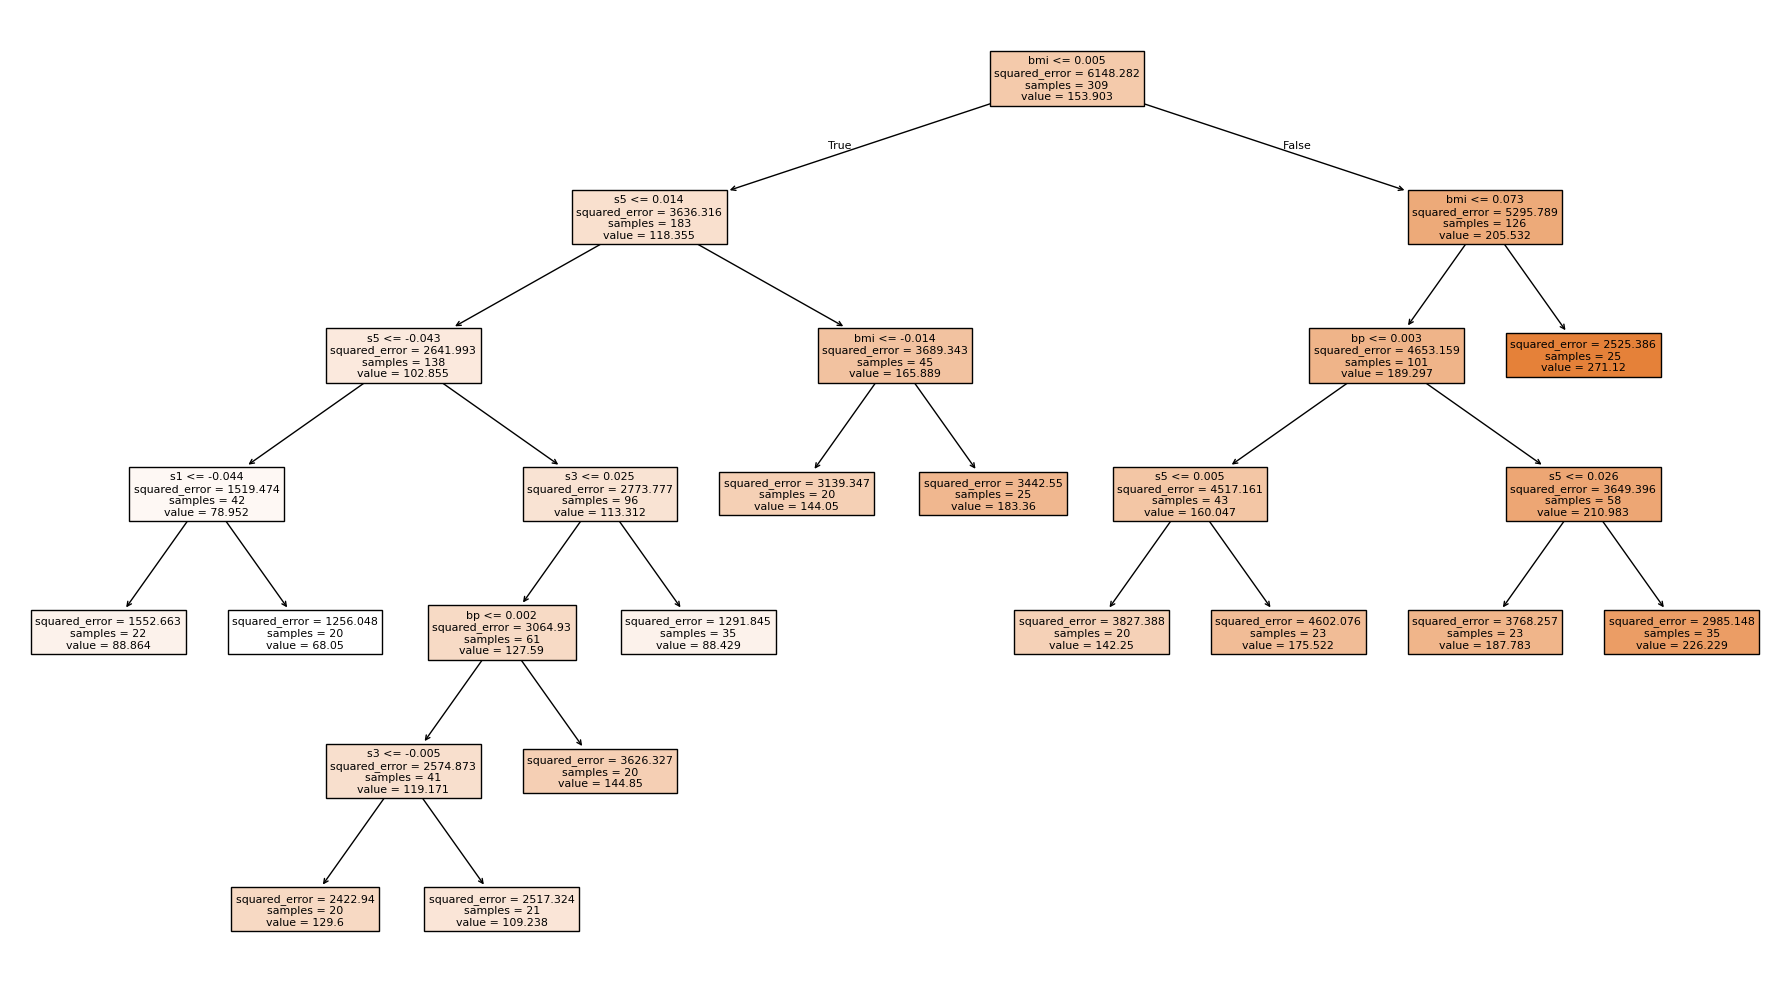

In [34]:
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)
plt.tight_layout()
plt.show()